In [1]:
%%time
%matplotlib inline

import importlib
import new_import  

importlib.reload(new_import)


from new_import import *

CPU times: user 13 s, sys: 3.32 s, total: 16.4 s
Wall time: 10.3 s


In [2]:
%%time
# Cấu hình Daskgateway
cluster, client = notebook_utils.initialize_dask(use_gateway=True, workers=(1,10))
# Khai báo 1 Datacube là dc
dc = datacube.Datacube()

client

Starting new cluster.
CPU times: user 697 ms, sys: 38.1 ms, total: 736 ms
Wall time: 2min 53s


Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: https://hub.asia.easi-eo.solutions/services/dask-gateway/clusters/easihub.247c1e48f7864d2e9d21d3beacbde30e/status,


In [130]:
date_range = ('2023-3-01', '2023-3-30')
longtitude_range = (105.5, 106.4)
latitude_range = (9.2, 10.0) 

coordinates = (longtitude_range, latitude_range)

In [131]:
# tải dữ liệu vh vv từ vệ tinh sentinel-1
dsvh, dsvv = load_data_sen1(dc, date_range, coordinates)

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 3, y: 8874, x: 9902)
Coordinates:
  * time         (time) datetime64[ns] 24B 2023-03-05T22:46:10.500000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
Data variables:
    vv           (time, y, x) float32 1GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    vh           (time, y, x) float32 1GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [132]:
average_vh = calculate_average(dsvh, time_pattern='1M')
progress(average_vh)

/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


VBox()

In [133]:
average_vv = calculate_average(dsvv, time_pattern='1M')
progress(average_vv)

/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


VBox()

In [134]:
%%time
average_vh.compute()
average_vv.compute()

CPU times: user 566 ms, sys: 750 ms, total: 1.32 s
Wall time: 1min 9s


<xarray.DataArray 'vv' (time: 1, y: 8874, x: 9902)> Size: 351MB
array([[[0.19917326, 0.2036858 , 0.20597248, ..., 0.23972352,
         0.23907872, 0.23844711],
        [0.19917326, 0.2036858 , 0.20597248, ..., 0.25530738,
         0.25576517, 0.25507364],
        [0.20632547, 0.20605431, 0.2029686 , ..., 0.28056654,
         0.28108242, 0.27629215],
        ...,
        [0.06841445, 0.07078951, 0.07297197, ..., 0.06806423,
         0.06924058, 0.06730109],
        [0.07230996, 0.07190628, 0.07310792, ..., 0.06789783,
         0.06905217, 0.06681374],
        [0.07501791, 0.07259221, 0.07343484, ..., 0.06789783,
         0.06905217, 0.06681374]]], dtype=float32)
Coordinates:
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
  * time         (time) datetime64[ns] 8B 2023-03-31
Attributes:
    units:         intensity
    nodata:        nan
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [135]:
data_sen2 = load_data_sen2(dc, date_range, coordinates)
notebook_utils.heading(notebook_utils.xarray_object_size(data_sen2))
display(data_sen2)

No datasets require offset correction
The valid_data_mask and scale (no offset) have been applied to the reflectance bands


<xarray.Dataset> Size: 9GB
Dimensions:      (time: 12, y: 8874, x: 9902)
Coordinates:
  * time         (time) datetime64[ns] 96B 2023-03-01T03:35:09.182000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
Data variables:
    red          (time, y, x) float32 4GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir          (time, y, x) float32 4GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    scl          (time, y, x) uint8 1GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [136]:
%%time
# Tiến hành loại bỏ các vị trí bị mây ảnh hưởng
result = mask_cloud(data_sen2)
progress(result)

{'0': 'no data',
 '1': 'saturated or defective',
 '2': 'dark area pixels',
 '3': 'cloud shadows',
 '4': 'vegetation',
 '5': 'bare soils',
 '6': 'water',
 '7': 'unclassified',
 '8': 'cloud medium probability',
 '9': 'cloud high probability',
 '10': 'thin cirrus',
 '11': 'snow or ice'}

CPU times: user 57.1 ms, sys: 4.1 ms, total: 61.2 ms
Wall time: 59.2 ms


VBox()

2025-01-13 15:34:16,456 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7fa1d24670e0>>, <Task finished name='Task-4823' coro=<MultiProgressBar.listen() done, defined at /env/lib/python3.12/site-packages/distributed/diagnostics/progressbar.py:281> exception=OSError('Timed out trying to connect to gateway://traefik-dask-gateway.easihub:80/easihub.247c1e48f7864d2e9d21d3beacbde30e after 30 s')>)
Traceback (most recent call last):
  File "/env/lib/python3.12/site-packages/distributed/utils.py", line 1952, in wait_for
    return await fut
           ^^^^^^^^^
  File "/env/lib/python3.12/site-packages/dask_gateway/comm.py", line 45, in connect
    plain_stream = await self.client.connect(
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/env/lib/python3.12/site-packages/tornado/tcpclient.py", line 269, in connect
    addrinfo = await self.resolver.resolve(host, por

In [137]:
# calculate NDVI
dsNDVI = calculate_indices(result, index='NDVI', satellite_mission='s2')
ndvi = dsNDVI["NDVI"]
display(ndvi)


<xarray.DataArray 'NDVI' (time: 12, y: 8874, x: 9902)> Size: 4GB
dask.array<truediv, shape=(12, 8874, 9902), dtype=float32, chunksize=(1, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 96B 2023-03-01T03:35:09.182000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648

In [138]:
%%time
# calculate average NDVI
average_ndvi = calculate_average(ndvi,time_pattern="1M")
progress(average_ndvi)

CPU times: user 21.3 ms, sys: 4.15 ms, total: 25.5 ms
Wall time: 29.2 ms


/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


VBox()

In [139]:
average_ndvi = average_ndvi.compute()

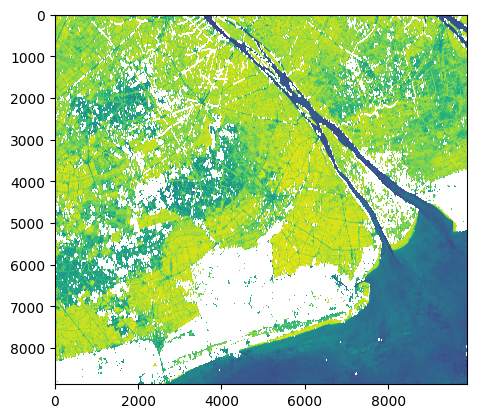

In [44]:
plt.imshow(average_ndvi.isel(time=0))

#####################################################################################

In [146]:
fill_nan_model = joblib.load('output/regressors/mean_no_negative/gb_cloud.pkl')

In [141]:
mask = ~np.isnan(average_ndvi) 
data = np.stack([average_vh.values[mask], average_vv.values[mask]], axis=1)
label = average_ndvi.values[mask]

In [142]:
label.shape

(85080123,)

In [143]:
num_samples = 5000000

# Generate random indices
random_indices = np.random.choice(data.shape[0], size=num_samples, replace=False)

# Subset the data using the random indices
x = data[random_indices]
y = label[random_indices]

# Check the new shape
print(x.shape)
print(y.shape)

(5000000, 2)
(5000000,)


In [144]:
# np.savez("input/saved_datasets/test_aug.npz", data=x, label=y)

In [147]:
preds = fill_nan_model.predict(x)
mse = mean_squared_error(y, preds)
mae = mean_absolute_error(y, preds)
r2 = r2_score(y, preds)
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R^2: {r2}")

MSE: 0.06232030271316629
MAE: 0.20292019157833405
R^2: 0.5583783284198397


#####################################################################################